# Alpaca candidate-fetch load test

Load-test Alpaca candidate retrieval using heuristic query plans.

Workflow:
1. Sample mentions from local source data.
2. Build heuristic query plans (`optimized_query = lookup_text`).
3. Build Alpaca Elasticsearch payloads with the production `build_alpaca_query()` helper.
4. Sweep parallel request counts.
5. Recommend the smallest stable parallelism near peak throughput.

Live Alpaca calls are disabled by default. Set `RUN_LIVE_CALLS = True` when you intentionally want to hit Alpaca.


In [1]:
from __future__ import annotations

import json
import os
import statistics
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from pprint import pprint
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

repo_root = Path.cwd()
if not (repo_root / "backend" / "app").exists():
    repo_root = repo_root.parent
assert (repo_root / "backend" / "app").exists(), f"Could not locate repo root from {Path.cwd()}"
sys.path.insert(0, str(repo_root / "backend"))

os.environ.setdefault("POSTGRES_HOST", "localhost")
os.environ.setdefault("POSTGRES_PORT", "5432")
os.environ.setdefault("POSTGRES_DB", "coverage_dashboard")
os.environ.setdefault("POSTGRES_USER", "postgres")
os.environ.setdefault("SOURCE_DATA_ROOT", str(repo_root / "Datasets"))

from app.datasets import build_random_sample_bundle_from_db
from app.retrieval import ALPACA_METADATA_URL, build_alpaca_query, extract_hits


def env_first(*names: str) -> str:
    for name in names:
        value = os.environ.get(name, "").strip()
        if value:
            return value
    return ""


## Knobs

In [2]:
RUN_LIVE_CALLS = True

SAMPLE_CONFIG = {
    "requested_datasets": ["2t-red"],
    "dataset_sample_size": 1,
    "tables_per_dataset": 4,
    "records_per_table": 128,
    "random_seed": 42,
    "context_rows": 2,
}

CANDIDATE_COUNT = 100
TIMEOUT_SECONDS = 60
PARALLEL_REQUESTS = [4, 8, 16, 32]
WAVES_PER_LEVEL = 4
MAX_ACCEPTABLE_P95_SECONDS = 10.0

ALPACA_ENDPOINT = os.environ.get("ALPACA_METADATA_URL", ALPACA_METADATA_URL)
ALPACA_TOKEN = env_first("ALPACA_TOKEN")

print("endpoint:", ALPACA_ENDPOINT)
print("token_set:", bool(ALPACA_TOKEN))


endpoint: https://alpaca.zooverse.dev/debug/elasticsearch/alpaca-entities/_search
token_set: True


## Build heuristic candidate requests

The heuristic plan matches production fallback behavior: the lookup text becomes the optimized query and no LLM type hints are added.


In [3]:
def heuristic_plan(sample: dict) -> dict:
    lookup_text = str(sample.get("lookup_text") or sample.get("mention_text") or "").strip()
    return {
        "optimized_query": lookup_text,
        "normalized_mention": None,
        "typo_corrected_mention": None,
        "typo_correction_confidence": None,
        "typo_correction_applied": False,
        "typo_correction_reason": None,
        "coarse_type": None,
        "fine_type": None,
        "wikipedia_url": None,
        "dbpedia_url": None,
        "aliases": [],
        "context_expansion_terms": [],
        "query_plan_source": "heuristic",
    }


def alpaca_request_for_sample(sample: dict, candidate_count: int) -> dict:
    plan = heuristic_plan(sample)
    query_text = str(plan.get("optimized_query") or sample.get("lookup_text") or sample.get("mention_text") or "").strip()
    payload = build_alpaca_query(query_text, plan)
    payload["size"] = int(candidate_count)
    return {
        "sample_id": sample["sample_id"],
        "mention_text": sample.get("mention_text"),
        "lookup_text": sample.get("lookup_text"),
        "query_text": query_text,
        "payload": payload,
    }


bundle = build_random_sample_bundle_from_db(SAMPLE_CONFIG)
samples = bundle["samples"]
requests = [alpaca_request_for_sample(sample, CANDIDATE_COUNT) for sample in samples]

print(f"samples={len(samples)} requests={len(requests)} warnings={len(bundle.get('warnings') or [])}")
pprint(bundle.get("sampling_manifest")[:8])
pprint(requests[:2])


samples=390 requests=390 warnings=0
[{'available_records': 140,
  'dataset': '2t-red',
  'sampled_records': 128,
  'table_id': '1H43KAA4'},
 {'available_records': 6,
  'dataset': '2t-red',
  'sampled_records': 6,
  'table_id': '4W2BISPA'},
 {'available_records': 213,
  'dataset': '2t-red',
  'sampled_records': 128,
  'table_id': 'Q7CDPWKD'},
 {'available_records': 164,
  'dataset': '2t-red',
  'sampled_records': 128,
  'table_id': 'QPFX5Z8J'}]
[{'lookup_text': 'caspian sea',
  'mention_text': 'Caspian Sea',
  'payload': {'_source': True,
              'query': {'bool': {'filter': [{'terms': {'item_category': ['ENTITY',
                                                                         'TYPE']}}],
                                 'minimum_should_match': 1,
                                 'should': [{'multi_match': {'boost': 4.0,
                                                             'fields': ['label^6',
                                                                      

## Direct Alpaca caller

This intentionally bypasses the local candidate cache by making direct HTTP requests to the Alpaca endpoint.


In [4]:
def call_alpaca(request_item: dict, request_index: int) -> dict:
    if not ALPACA_TOKEN:
        return {
            "request_index": request_index,
            "sample_id": request_item.get("sample_id"),
            "query_text": request_item.get("query_text"),
            "error": "missing_alpaca_token",
        }
    started = time.monotonic()
    payload = dict(request_item["payload"])
    http_request = Request(
        ALPACA_ENDPOINT,
        data=json.dumps(payload).encode("utf-8"),
        headers={
            "accept": "application/json",
            "Content-Type": "application/json",
            "Authorization": f"Bearer {ALPACA_TOKEN}",
            "User-Agent": "coverage-dashboard-alpaca-load-test/1.0",
        },
        method="POST",
    )
    try:
        with urlopen(http_request, timeout=TIMEOUT_SECONDS) as response:
            raw = response.read() or b"{}"
            response_payload = json.loads(raw)
            hits = extract_hits(response_payload)
            return {
                "request_index": request_index,
                "sample_id": request_item.get("sample_id"),
                "query_text": request_item.get("query_text"),
                "http_status": getattr(response, "status", None),
                "seconds": round(time.monotonic() - started, 3),
                "hit_count": len(hits),
                "payload_bytes": len(json.dumps(payload, ensure_ascii=False).encode("utf-8")),
                "error": None,
            }
    except HTTPError as exc:
        detail = exc.read().decode("utf-8", errors="replace")
        error = f"HTTP {exc.code}: {detail[:240]}"
    except (URLError, TimeoutError, json.JSONDecodeError) as exc:
        error = str(exc)
    return {
        "request_index": request_index,
        "sample_id": request_item.get("sample_id"),
        "query_text": request_item.get("query_text"),
        "seconds": round(time.monotonic() - started, 3),
        "error": error,
    }


if RUN_LIVE_CALLS:
    pprint(call_alpaca(requests[0], 0))
else:
    print("Live calls disabled. Set RUN_LIVE_CALLS = True to run the smoke call.")


{'error': None,
 'hit_count': 100,
 'http_status': 200,
 'payload_bytes': 458,
 'query_text': 'caspian sea',
 'request_index': 0,
 'sample_id': '2t-red::1H43KAA4::1::1',
 'seconds': 0.226}


## Parallel load sweep

For each parallelism level, the notebook sends `parallelism * WAVES_PER_LEVEL` requests. This gives each level enough work to measure throughput beyond the first wave.


In [5]:
def percentile(values: list[float], pct: float) -> float | None:
    if not values:
        return None
    ordered = sorted(values)
    index = min(len(ordered) - 1, max(0, round((pct / 100) * (len(ordered) - 1))))
    return ordered[index]


def request_items_for_level(parallelism: int) -> list[dict]:
    needed = parallelism * WAVES_PER_LEVEL
    if not requests:
        return []
    return [requests[index % len(requests)] for index in range(needed)]


def summarize_level(parallelism: int, children: list[dict], wall_seconds: float) -> dict:
    latencies = [float(item["seconds"]) for item in children if item.get("seconds") is not None and not item.get("error")]
    errors = [item.get("error") for item in children if item.get("error")]
    hit_counts = [int(item.get("hit_count") or 0) for item in children if not item.get("error")]
    success_count = len(children) - len(errors)
    return {
        "parallelism": parallelism,
        "requests": len(children),
        "success_count": success_count,
        "error_count": len(errors),
        "success_rate": round(success_count / max(1, len(children)), 3),
        "wall_seconds": round(wall_seconds, 3),
        "requests_per_second": round(success_count / max(wall_seconds, 0.001), 3),
        "p50_seconds": round(statistics.median(latencies), 3) if latencies else None,
        "p95_seconds": round(percentile(latencies, 95), 3) if latencies else None,
        "max_seconds": round(max(latencies), 3) if latencies else None,
        "avg_hit_count": round(sum(hit_counts) / len(hit_counts), 1) if hit_counts else None,
        "errors": errors[:5],
        "children": children,
    }


load_results = []

if RUN_LIVE_CALLS:
    for parallelism in PARALLEL_REQUESTS:
        level_requests = request_items_for_level(parallelism)
        started = time.monotonic()
        with ThreadPoolExecutor(max_workers=parallelism) as executor:
            futures = [executor.submit(call_alpaca, item, index) for index, item in enumerate(level_requests)]
            children = [future.result() for future in as_completed(futures)]
        summary = summarize_level(parallelism, children, time.monotonic() - started)
        load_results.append(summary)
        pprint(summary)
else:
    print("Live calls disabled. Set RUN_LIVE_CALLS = True to run the load sweep.")


{'avg_hit_count': 100.0,
 'children': [{'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 458,
               'query_text': 'caspian sea',
               'request_index': 0,
               'sample_id': '2t-red::1H43KAA4::1::1',
               'seconds': 0.13},
              {'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 453,
               'query_text': 'russia',
               'request_index': 2,
               'sample_id': '2t-red::1H43KAA4::2::2',
               'seconds': 0.137},
              {'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 458,
               'query_text': 'caspian sea',
               'request_index': 3,
               'sample_id': '2t-red::1H43KAA4::3::1',
               'seconds': 0.165},
              {'error': None,
               'hit_count': 100,
            

## Recommendation

Stable means no request errors and p95 latency under `MAX_ACCEPTABLE_P95_SECONDS`. The recommendation is the smallest stable parallelism within 90% of the best stable throughput.


In [6]:
def choose_parallelism(results: list[dict]) -> dict | None:
    if not results:
        return None
    stable = [
        item for item in results
        if item.get("error_count") == 0
        and item.get("success_rate") == 1
        and item.get("p95_seconds") is not None
        and item["p95_seconds"] <= MAX_ACCEPTABLE_P95_SECONDS
    ]
    if stable:
        peak = max(item["requests_per_second"] for item in stable)
        near_peak = [item for item in stable if item["requests_per_second"] >= peak * 0.90]
        chosen = sorted(near_peak, key=lambda item: (item["parallelism"], item["p95_seconds"]))[0]
        return {**chosen, "rationale": "smallest stable parallelism within 90% of best stable throughput"}
    chosen = sorted(results, key=lambda item: (-item.get("success_rate", 0), item.get("p95_seconds") or 10**9, -item.get("requests_per_second", 0)))[0]
    return {**chosen, "rationale": "no fully stable level; chose highest success rate with lowest p95 latency"}


recommended_load_config = choose_parallelism(load_results)
print("Recommended Alpaca candidate-fetch load config:")
pprint(recommended_load_config)

if recommended_load_config:
    print("\nUse this config:")
    print(f"parallel_requests={recommended_load_config['parallelism']}")
    print(f"candidate_count={CANDIDATE_COUNT}")
    print(f"observed_requests_per_second={recommended_load_config['requests_per_second']}")
    print(f"observed_p95_seconds={recommended_load_config['p95_seconds']}")
else:
    print("No recommendation yet. Run the load sweep first.")


Recommended Alpaca candidate-fetch load config:
{'avg_hit_count': 94.2,
 'children': [{'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 457,
               'query_text': 'azerbaijan',
               'request_index': 6,
               'sample_id': '2t-red::1H43KAA4::4::2',
               'seconds': 0.316},
              {'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 452,
               'query_text': 'huron',
               'request_index': 17,
               'sample_id': '2t-red::1H43KAA4::11::1',
               'seconds': 0.316},
              {'error': None,
               'hit_count': 100,
               'http_status': 200,
               'payload_bytes': 453,
               'query_text': 'uganda',
               'request_index': 12,
               'sample_id': '2t-red::1H43KAA4::8::2',
               'seconds': 0.342},
              {'error': None,
 

## Visualization

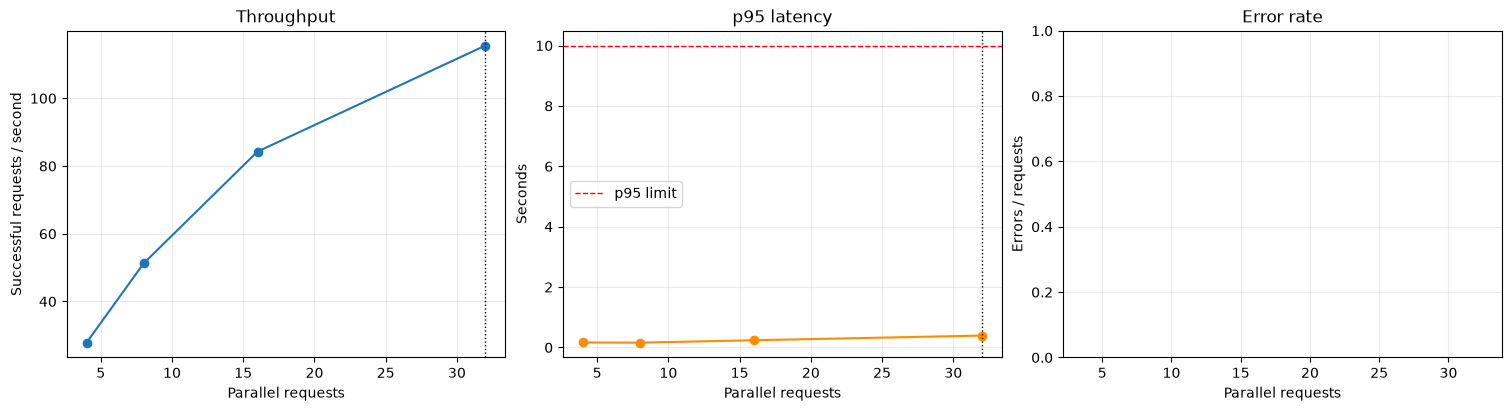

In [7]:
import matplotlib.pyplot as plt


def plot_load_results(results: list[dict], recommendation: dict | None) -> None:
    if not results:
        print("No load results to plot yet.")
        return
    rows = sorted(results, key=lambda item: item["parallelism"])
    x = [item["parallelism"] for item in rows]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    axes[0].plot(x, [item["requests_per_second"] for item in rows], marker="o")
    axes[0].set_title("Throughput")
    axes[0].set_xlabel("Parallel requests")
    axes[0].set_ylabel("Successful requests / second")
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(x, [item["p95_seconds"] or 0 for item in rows], marker="o", color="darkorange")
    axes[1].axhline(MAX_ACCEPTABLE_P95_SECONDS, color="red", linestyle="--", linewidth=1, label="p95 limit")
    axes[1].set_title("p95 latency")
    axes[1].set_xlabel("Parallel requests")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc="best")

    axes[2].bar(x, [item["error_count"] / max(1, item["requests"]) for item in rows], color="crimson")
    axes[2].set_title("Error rate")
    axes[2].set_xlabel("Parallel requests")
    axes[2].set_ylabel("Errors / requests")
    axes[2].set_ylim(0, 1)
    axes[2].grid(True, alpha=0.25)

    if recommendation:
        for ax in axes[:2]:
            ax.axvline(recommendation["parallelism"], color="black", linestyle=":", linewidth=1)
    plt.show()


plot_load_results(load_results, recommended_load_config)


## Optional: save results

In [8]:
SAVE_RESULTS = False

if SAVE_RESULTS:
    output = {
        "endpoint": ALPACA_ENDPOINT,
        "candidate_count": CANDIDATE_COUNT,
        "parallel_requests": PARALLEL_REQUESTS,
        "waves_per_level": WAVES_PER_LEVEL,
        "sample_config": SAMPLE_CONFIG,
        "load_results": load_results,
        "recommended_load_config": recommended_load_config,
    }
    path = f"alpaca_candidate_load_test_{int(time.time())}.json"
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(output, handle, indent=2, ensure_ascii=False)
    print(path)
else:
    print("Set SAVE_RESULTS = True to write the benchmark results JSON.")


Set SAVE_RESULTS = True to write the benchmark results JSON.
